# **Step 1: Install Required Libraries**

In [1]:
pip install tensorflow keras numpy pandas matplotlib opencv-python scikit-learn

# **Step 2: Import Required Libraries**

In [2]:
# Import deep learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Import utility libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.model_selection import train_test_split

# **Step 3: Understanding the Dataset Structure**

In [3]:
# Mount the Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

# Define the dataset path (Update this with the actual folder location)
dataset_path = "/content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Dataset/Brain Tumor MRI Dataset"

# Check structure of dataset
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        print(f"📂 Folder: {folder}")

        # Display some sample files
        sample_files = os.listdir(folder_path)[:5]  # Show first 5 images
        print("  ↳ Example files:", sample_files)

📂 Folder: Training
  ↳ Example files: ['notumor', 'meningioma', 'pituitary', 'glioma']
📂 Folder: Testing
  ↳ Example files: ['pituitary', 'meningioma', 'glioma', 'notumor']


# **Step 4: Loading and Preprocessing Images**

In [5]:
import cv2
import numpy as np

# Define dataset paths (Update with correct location)
train_path = "/content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Dataset/Brain Tumor MRI Dataset/Training"
test_path = "/content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Dataset/Brain Tumor MRI Dataset/Testing"

# Define image size
IMG_SIZE = (224, 224)

# Define categories
classes = ["glioma", "meningioma", "pituitary", "notumor"]

# Function to load images from folder
def load_images_from_folder(folder_path):
    images, labels = [], []

    for label, class_name in enumerate(classes):
        class_folder = os.path.join(folder_path, class_name)

        for img_file in os.listdir(class_folder):
            img_path = os.path.join(class_folder, img_file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale
            img = cv2.resize(img, IMG_SIZE)  # Resize to 224×224
            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load training and testing datasets
X_train, y_train = load_images_from_folder(train_path)
X_test, y_test = load_images_from_folder(test_path)

# Normalize images (convert pixel values to range 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN compatibility
X_train = X_train.reshape(-1, 224, 224, 1)
X_test = X_test.reshape(-1, 224, 224, 1)

print(f" Dataset Loaded Successfully!")
print(f"Training Samples: {X_train.shape[0]}, Testing Samples: {X_test.shape[0]}")

 Dataset Loaded Successfully!
Training Samples: 5712, Testing Samples: 1311


# **Step 5: Splitting the Dataset into Train, Validation, and Test Sets**

In [6]:
from sklearn.model_selection import train_test_split

# Split training data into Train (80%) & Validation (20%)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(f" Dataset Split Completed!")
print(f"Final Training Samples: {X_train.shape[0]}, Validation Samples: {X_val.shape[0]}, Testing Samples: {X_test.shape[0]}")

 Dataset Split Completed!
Final Training Samples: 4569, Validation Samples: 1143, Testing Samples: 1311


# **Step 6: Visualizing Sample Images**

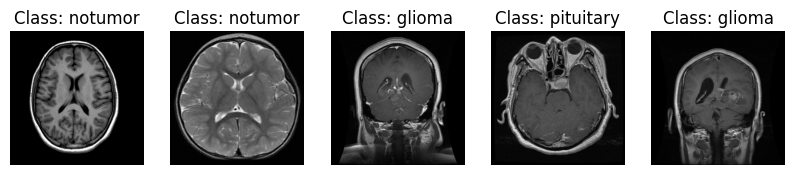

In [7]:
import matplotlib.pyplot as plt

# Function to display sample images
def show_sample_images(X, y, class_names, num_samples=5):
    plt.figure(figsize=(10, 5))

    for i in range(num_samples):
        plt.subplot(1, num_samples, i+1)
        plt.imshow(X[i].reshape(224, 224), cmap="gray")  # Display grayscale image
        plt.title(f"Class: {class_names[y[i]]}")  # Show class label
        plt.axis("off")  # Hide axes

    plt.show()

# Display sample images from training data
show_sample_images(X_train, y_train, classes)

# **Step 7: Building the CNN Model**

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Define CNN model architecture
model = Sequential([
    # First Convolutional Block
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(224, 224, 1)),
    MaxPooling2D(pool_size=(2,2)),
    BatchNormalization(),

    # Second Convolutional Block
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    BatchNormalization(),

    # Third Convolutional Block
    Conv2D(128, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    BatchNormalization(),

    # Flattening the Feature Maps
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),
    Dropout(0.5),  # Prevents overfitting

    # Output Layer (4 classes)
    Dense(4, activation='softmax')
])

# Display model summary
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 111, 111, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 54, 54, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,796 (42.61 MB)

 Trainable params: 11,169,348 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

# **Step 8: Compiling and Training the CNN Model**

In [9]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)

Epoch 1/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 26s 107ms/step - accuracy: 0.4983 - loss: 5.0160 - val_accuracy: 0.2388 - val_loss: 17.2879
Epoch 2/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.4709 - loss: 1.1803 - val_accuracy: 0.2388 - val_loss: 7.6382
Epoch 3/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.5012 - loss: 1.1057 - val_accuracy: 0.4068 - val_loss: 1.6567
Epoch 4/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.5604 - loss: 0.9690 - val_accuracy: 0.5774 - val_loss: 1.0507
Epoch 5/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.5703 - loss: 0.9000 - val_accuracy: 0.7104 - val_loss: 0.7862
Epoch 6/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.5929 - loss: 0.8944 - val_accuracy: 0.7577 - val_loss: 0.6362
Epoch 7/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.6218 - loss: 0.8497 - val_accuracy: 0.7515 - val_loss: 0.5988
Epoch 8/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.6292 - loss: 0.8055 - v

# **Step 9: Evaluating Model Performance**

In [10]:
# Evaluate model on the test dataset
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f" Test Accuracy: {test_accuracy:.4f}")
print(f" Test Loss: {test_loss:.4f}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.4541 - loss: 1.7128
 Test Accuracy: 0.6201
 Test Loss: 1.6310


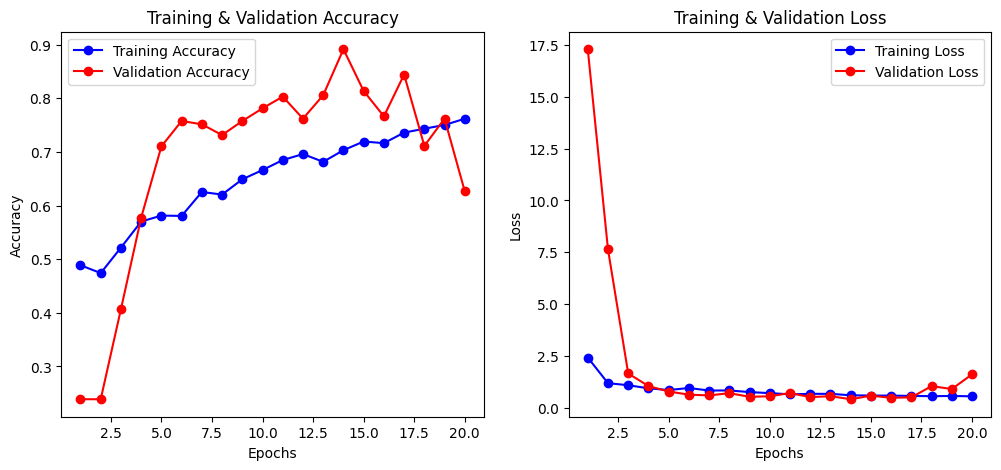

In [11]:
import matplotlib.pyplot as plt

# Extract loss & accuracy from training history
epochs = range(1, 21)
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot Accuracy Curve
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

# Plot Loss Curve
plt.subplot(1,2,2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

plt.show()

# **Step 10: Making Predictions on New MRI Images**

In [16]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.8, 1.2], # Adjust brightness
    horizontal_flip=True
)

X_train_augmented = train_datagen.flow(X_train, y_train, batch_size=32)

In [17]:
model.add(Dropout(0.5))  # Apply dropout after dense layers

In [18]:
X_test = X_test / 255.0  # Normalize images
X_test = X_test.reshape(-1, 224, 224, 1)  # Reshape for model input

In [19]:
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30)

Epoch 1/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.7508 - loss: 0.5870 - val_accuracy: 0.8416 - val_loss: 0.4236
Epoch 2/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.7550 - loss: 0.5419 - val_accuracy: 0.8968 - val_loss: 0.3910
Epoch 3/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.7762 - loss: 0.5083 - val_accuracy: 0.8460 - val_loss: 0.7507
Epoch 4/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.7684 - loss: 0.5520 - val_accuracy: 0.6859 - val_loss: 2.6701
Epoch 5/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.7662 - loss: 0.5436 - val_accuracy: 0.8198 - val_loss: 0.4446
Epoch 6/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.7794 - loss: 0.5086 - val_accuracy: 0.8968 - val_loss: 0.3669
Epoch 7/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.7748 - loss: 0.5164 - val_accuracy: 0.9116 - val_loss: 0.4123
Epoch 8/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.7994 - loss: 0.4556 - val_a

In [20]:
import random

# Pick random test samples
random_indices = random.sample(range(len(X_test)), 5)

for idx in random_indices:
    img = X_test[idx]
    actual_label = classes[y_test[idx]]

    pred = model.predict(img.reshape(1, 224, 224, 1))
    predicted_label = classes[np.argmax(pred)]

    print(f"Actual: {actual_label}, Predicted: {predicted_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
Actual: glioma, Predicted: notumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Actual: pituitary, Predicted: notumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step
Actual: pituitary, Predicted: notumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
Actual: meningioma, Predicted: notumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Actual: pituitary, Predicted: notumor
